In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [83]:
# Styling
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("Set2")

print("Libraries loaded successfully")

Libraries loaded successfully


In [84]:
# Load data  
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

# Copy of original test IDs for final submission  
test_ids = test['PassengerId'].copy()

# Combine for joint preprocessing(we will split back later)
df = pd.concat([train, test], axis=0, ignore_index=True)

print(f"Train shape: {train.shape}")
print(f"Test shape : {test.shape}")
print(f"Combined : {df.shape}")
df.head()


Train shape: (891, 12)
Test shape : (418, 11)
Combined : (1309, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [85]:
# Initial data audit
print("=" * 50)
print("MISSING VALUES")
print("=" * 50)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
audit = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(audit[audit['Missing Count'] > 0].sort_values('Missing %', ascending=False))

print("\n" + "=" * 50)
print("DATA TYPES & BASIC STATS")
print("=" * 50)
print(df.dtypes)
print("\nOverall survival rate:", round(train['Survived'].mean() * 100, 2), "%")

MISSING VALUES
          Missing Count  Missing %
Cabin              1014      77.46
Survived            418      31.93
Age                 263      20.09
Embarked              2       0.15
Fare                  1       0.08

DATA TYPES & BASIC STATS
PassengerId      int64
Survived       float64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Overall survival rate: 38.38 %


In [86]:
# --- CREATE PROJECT FOLDERS ---
import os

os.makedirs('../outputs', exist_ok=True)
os.makedirs('../data', exist_ok=True)

print("Folders created successfully")

Folders created successfully


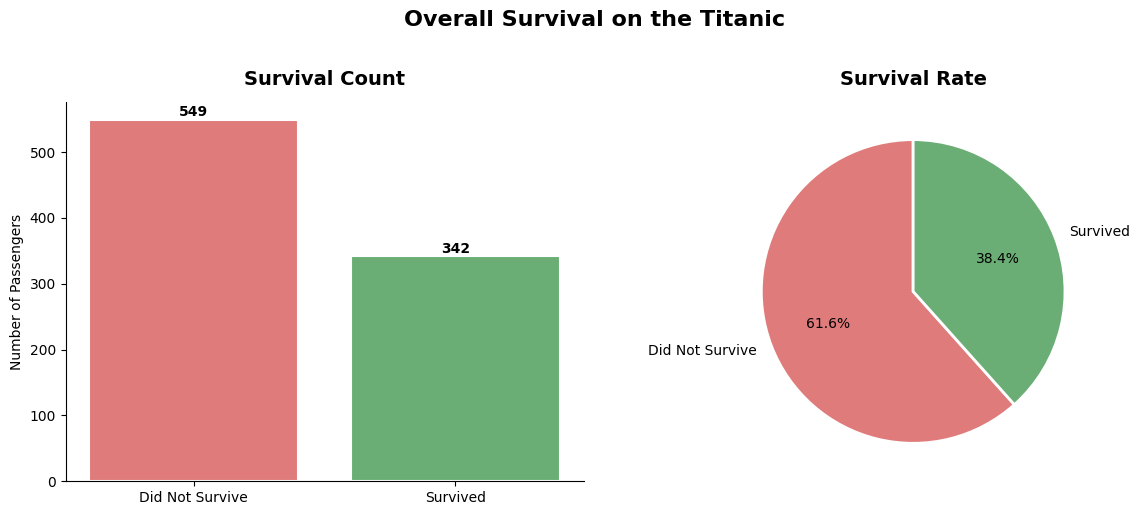

Insight: Only 38.4% of passengers survived.
The dataset is moderately imbalanced — we'll account for this in modelling.


In [87]:
# Survival Overview
fig, axes = plt.subplots(1,2, figsize=(12,5))

# overall survival count
survival_counts = train['Survived'].value_counts()
axes[0].bar(['Did Not Survive', 'Survived'], survival_counts.values,
            color = ['#E07B7B', '#6BAE75'], edgecolor='white', linewidth = 1.5)
axes[0].set_title('Survival Count', fontsize=14, fontweight ='bold', pad=12)
axes[0].set_ylabel('Number of Passengers')
for i, v in enumerate(survival_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight = 'bold')

# Survival rate pie
axes[1].pie(survival_counts.values,
            labels=['Did Not Survive', 'Survived'],
            autopct='%1.1f%%',
            colors=['#E07B7B', '#6BAE75'],
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Survival Rate', fontsize=14, fontweight='bold', pad=12)

plt.suptitle('Overall Survival on the Titanic', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/01_survival_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("Insight: Only 38.4% of passengers survived.")
print("The dataset is moderately imbalanced — we'll account for this in modelling.")

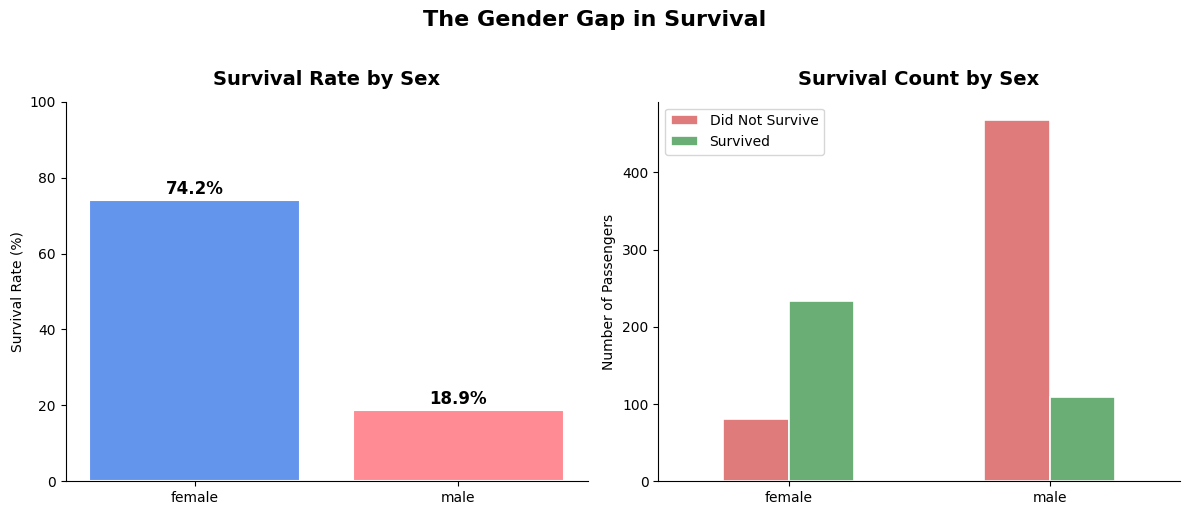

Insight: Women survived at 74.2% vs men at only 18.9%.
   'Women and children first' was clearly enforced on the Titanic.


In [88]:
# --- 5. SURVIVAL BY SEX ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sex_survival = train.groupby('Sex')['Survived'].mean().reset_index()
sex_survival['Survived_pct'] = (sex_survival['Survived'] * 100).round(1)

# Bar chart
bars = axes[0].bar(sex_survival['Sex'], sex_survival['Survived_pct'],
                   color=['#6495ED', '#FF8C94'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Survival Rate by Sex', fontsize=14, fontweight='bold', pad=12)
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_ylim(0, 100)
for bar, val in zip(bars, sex_survival['Survived_pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                 f'{val}%', ha='center', fontweight='bold', fontsize=12)

# Count split
sex_count = train.groupby(['Sex', 'Survived']).size().unstack()
sex_count.plot(kind='bar', ax=axes[1],
               color=['#E07B7B', '#6BAE75'],
               edgecolor='white', linewidth=1.2)
axes[1].set_title('Survival Count by Sex', fontsize=14, fontweight='bold', pad=12)
axes[1].set_ylabel('Number of Passengers')
axes[1].set_xlabel('')
axes[1].legend(['Did Not Survive', 'Survived'])
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('The Gender Gap in Survival', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/02_survival_by_sex.png', dpi=150, bbox_inches='tight')
plt.show()

print("Insight: Women survived at 74.2% vs men at only 18.9%.")
print("   'Women and children first' was clearly enforced on the Titanic.")

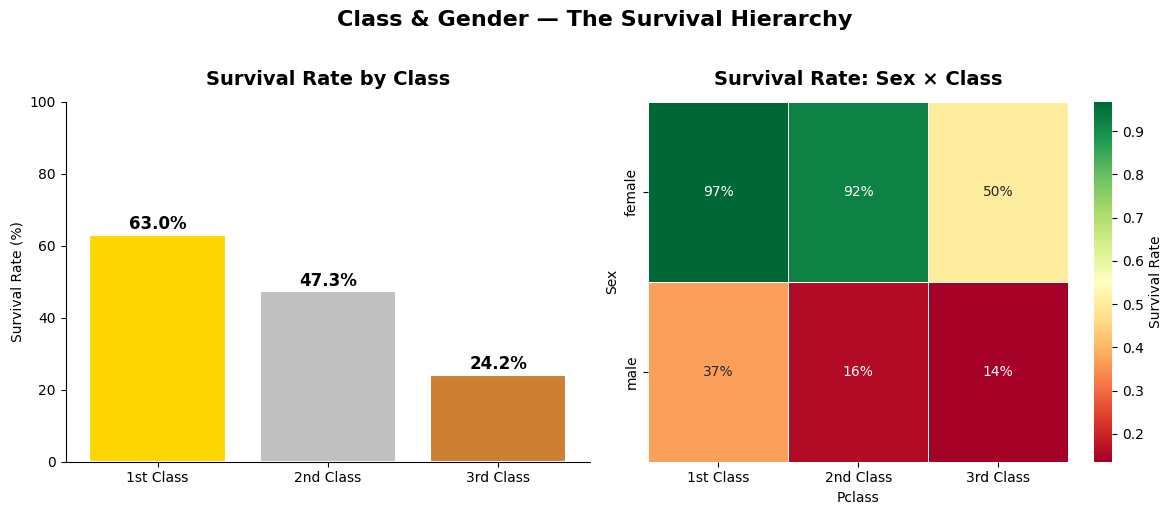

Insight: 1st class passengers survived at 63% vs 24% in 3rd class.
   A 3rd-class woman (74%) still outlived a 1st-class man (37%).
   Sex was a stronger survival signal than wealth.


In [89]:
# --- 6. SURVIVAL BY PASSENGER CLASS ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

pclass_survival = train.groupby('Pclass')['Survived'].mean().reset_index()
pclass_survival['Survived_pct'] = (pclass_survival['Survived'] * 100).round(1)
class_labels = ['1st Class', '2nd Class', '3rd Class']

bars = axes[0].bar(class_labels, pclass_survival['Survived_pct'],
                   color=['#FFD700', '#C0C0C0', '#CD7F32'],
                   edgecolor='white', linewidth=1.5)
axes[0].set_title('Survival Rate by Class', fontsize=14, fontweight='bold', pad=12)
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_ylim(0, 100)
for bar, val in zip(bars, pclass_survival['Survived_pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                 f'{val}%', ha='center', fontweight='bold', fontsize=12)

# Heatmap: Sex x Pclass survival
pivot = train.pivot_table(values='Survived', index='Sex', columns='Pclass', aggfunc='mean')
sns.heatmap(pivot, ax=axes[1], annot=True, fmt='.0%',
            cmap='RdYlGn', linewidths=0.5,
            cbar_kws={'label': 'Survival Rate'})
axes[1].set_title('Survival Rate: Sex × Class', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xticklabels(['1st Class', '2nd Class', '3rd Class'])

plt.suptitle('Class & Gender — The Survival Hierarchy', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/03_survival_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

print("Insight: 1st class passengers survived at 63% vs 24% in 3rd class.")
print("   A 3rd-class woman (74%) still outlived a 1st-class man (37%).")
print("   Sex was a stronger survival signal than wealth.")

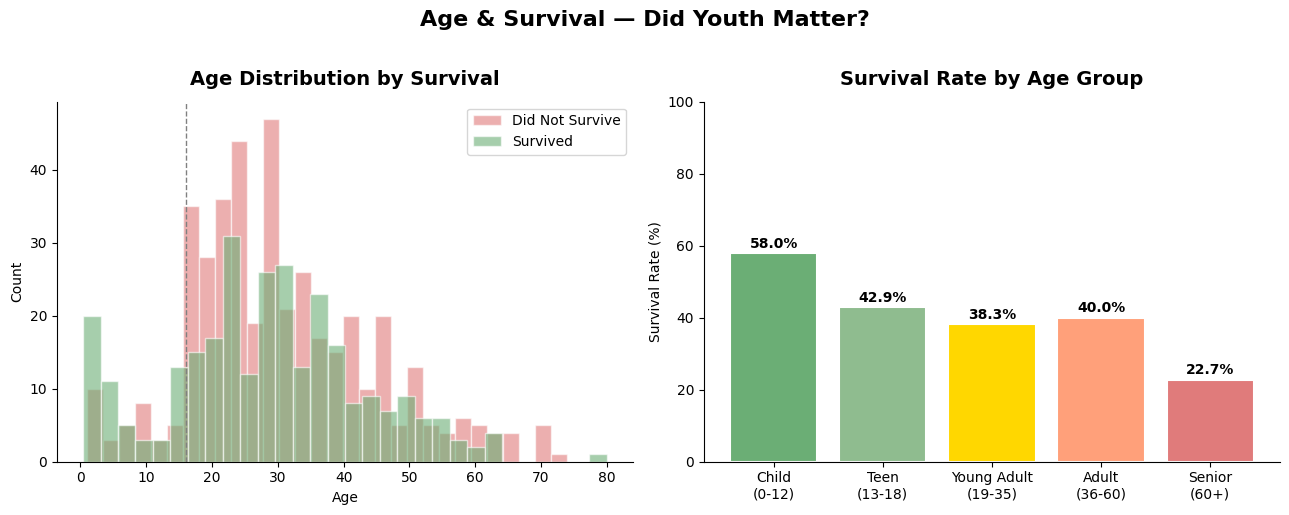

Insight: Children had the highest survival rate (~57%).
   Seniors had the lowest. Age mattered — but less than sex or class.


In [90]:
# --- 7. AGE DISTRIBUTION & SURVIVAL ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Age distribution by survival
survived     = train[train['Survived'] == 1]['Age'].dropna()
not_survived = train[train['Survived'] == 0]['Age'].dropna()

axes[0].hist(not_survived, bins=30, alpha=0.6, color='#E07B7B', label='Did Not Survive', edgecolor='white')
axes[0].hist(survived,     bins=30, alpha=0.6, color='#6BAE75', label='Survived',        edgecolor='white')
axes[0].set_title('Age Distribution by Survival', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].axvline(x=16, color='gray', linestyle='--', linewidth=1, label='Age 16')

# Age group survival rate
train['AgeGroup_temp'] = pd.cut(train['Age'],
                                bins=[0, 12, 18, 35, 60, 100],
                                labels=['Child\n(0-12)', 'Teen\n(13-18)',
                                        'Young Adult\n(19-35)', 'Adult\n(36-60)', 'Senior\n(60+)'])
age_surv = train.groupby('AgeGroup_temp', observed=True)['Survived'].mean() * 100

axes[1].bar(age_surv.index, age_surv.values,
            color=['#6BAE75', '#8FBC8F', '#FFD700', '#FFA07A', '#E07B7B'],
            edgecolor='white', linewidth=1.5)
axes[1].set_title('Survival Rate by Age Group', fontsize=14, fontweight='bold', pad=12)
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 100)
for i, val in enumerate(age_surv.values):
    axes[1].text(i, val + 1.5, f'{val:.1f}%', ha='center', fontweight='bold')

train.drop(columns=['AgeGroup_temp'], inplace=True)

plt.suptitle('Age & Survival — Did Youth Matter?', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/04_survival_by_age.png', dpi=150, bbox_inches='tight')
plt.show()

print("Insight: Children had the highest survival rate (~57%).")
print("   Seniors had the lowest. Age mattered — but less than sex or class.")

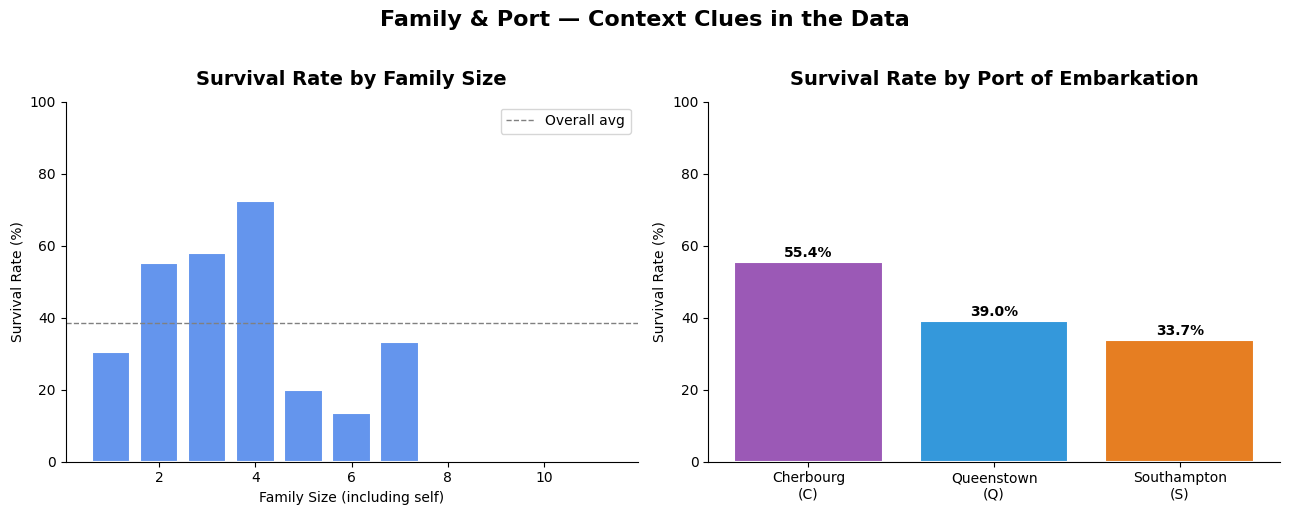

Insight: Solo travellers and very large families (7+) had low survival.
   Small families of 2-4 had the best odds — enough to help each other.
   Cherbourg passengers survived most — they were disproportionately 1st class.


In [91]:
# --- 8. FAMILY SIZE & EMBARKATION ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Family size vs survival
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
family_surv = train.groupby('FamilySize')['Survived'].mean() * 100

axes[0].bar(family_surv.index, family_surv.values,
            color='#6495ED', edgecolor='white', linewidth=1.5)
axes[0].set_title('Survival Rate by Family Size', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Family Size (including self)')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_ylim(0, 100)
axes[0].axhline(y=38.4, color='gray', linestyle='--', linewidth=1, label='Overall avg')
axes[0].legend()

# Embarkation survival
emb_surv = train.groupby('Embarked')['Survived'].mean() * 100
emb_labels = {'C': 'Cherbourg\n(C)', 'Q': 'Queenstown\n(Q)', 'S': 'Southampton\n(S)'}
axes[1].bar([emb_labels[e] for e in emb_surv.index], emb_surv.values,
            color=['#9B59B6', '#3498DB', '#E67E22'],
            edgecolor='white', linewidth=1.5)
axes[1].set_title('Survival Rate by Port of Embarkation', fontsize=14, fontweight='bold', pad=12)
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 100)
for i, val in enumerate(emb_surv.values):
    axes[1].text(i, val + 1.5, f'{val:.1f}%', ha='center', fontweight='bold')

train.drop(columns=['FamilySize'], inplace=True)

plt.suptitle('Family & Port — Context Clues in the Data', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/05_family_embarkation.png', dpi=150, bbox_inches='tight')
plt.show()

print("Insight: Solo travellers and very large families (7+) had low survival.")
print("   Small families of 2-4 had the best odds — enough to help each other.")
print("   Cherbourg passengers survived most — they were disproportionately 1st class.")

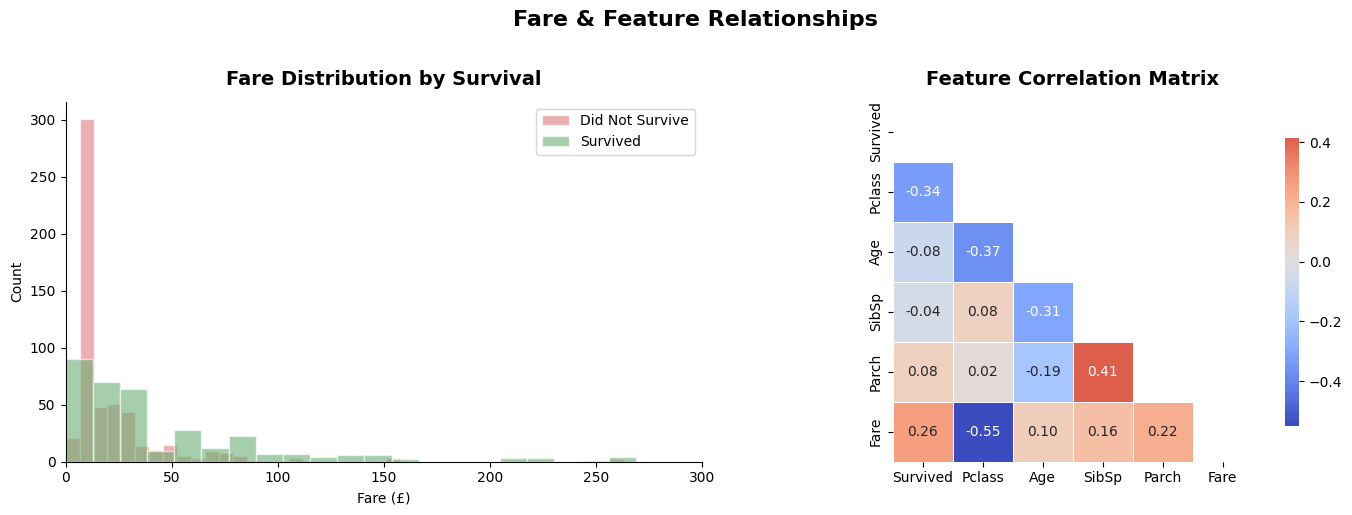

Insight: Higher fare strongly correlates with survival — proxy for class.
   Pclass has a negative correlation with survival (higher number = lower class).
   Age has a slight negative correlation — older passengers were less likely to survive.


In [92]:
# --- 9. FARE & CORRELATION HEATMAP ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fare by survival
survived_fare     = train[train['Survived'] == 1]['Fare']
not_survived_fare = train[train['Survived'] == 0]['Fare']

axes[0].hist(not_survived_fare, bins=40, alpha=0.6, color='#E07B7B',
             label='Did Not Survive', edgecolor='white')
axes[0].hist(survived_fare, bins=40, alpha=0.6, color='#6BAE75',
             label='Survived', edgecolor='white')
axes[0].set_xlim(0, 300)
axes[0].set_title('Fare Distribution by Survival', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Fare (£)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Correlation heatmap
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr = train[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=axes[1], mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            square=True, cbar_kws={'shrink': 0.8})
axes[1].set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=12)

plt.suptitle('Fare & Feature Relationships', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/06_fare_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("Insight: Higher fare strongly correlates with survival — proxy for class.")
print("   Pclass has a negative correlation with survival (higher number = lower class).")
print("   Age has a slight negative correlation — older passengers were less likely to survive.")

Extract Titles from Names  

Why? The Name column looks useless at first glance, but it contains titles like Mr, Mrs, Miss, Master, Dr, Rev. These titles carry hidden information — Master means a male child, Miss often means unmarried young woman. Titles are a smarter proxy for age and social status combined than age alone (which has 177 missing values).

In [93]:
# --- 10. FEATURE ENGINEERING: TITLE EXTRACTION ---

# Extract title from Name column
df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.')

print("Raw titles found:")
print(df['Title'].value_counts())

Raw titles found:
Title
Mr              757
Miss            260
Mrs             197
Master           61
Rev               8
Dr                8
Col               4
Major             2
Mlle              2
Ms                2
Mme               1
Don               1
Sir               1
Lady              1
Capt              1
the Countess      1
Jonkheer          1
Dona              1
Name: count, dtype: int64


Clean & Group Titles  

Why? Rare titles like Jonkheer, Capt, Col, the Countess appear only once or twice — not enough for the model to learn from. We group them into a Rare bucket so the model sees a meaningful category rather than noise. French titles (Mme, Mlle) map to their English equivalents.

In [94]:
# --- 11. CLEAN & GROUP TITLES ---

# Map rare/foreign titles to standard ones
title_mapping = {
    'Mme'        : 'Mrs',
    'Ms'         : 'Miss',
    'Mlle'       : 'Miss',
    'Lady'       : 'Rare',
    'the Countess': 'Rare',
    'Capt'       : 'Rare',
    'Col'        : 'Rare',
    'Don'        : 'Rare',
    'Dr'         : 'Rare',
    'Major'      : 'Rare',
    'Rev'        : 'Rare',
    'Sir'        : 'Rare',
    'Jonkheer'   : 'Rare',
    'Dona'       : 'Rare'
}

df['Title'] = df['Title'].replace(title_mapping)

print("Cleaned titles:")
print(df['Title'].value_counts())

# Survival rate by title (train rows only)
title_surv = df[df['Survived'].notna()].groupby('Title')['Survived'].mean().round(3)
print("\nSurvival rate by title:")
print(title_surv)

Cleaned titles:
Title
Mr        757
Miss      264
Mrs       198
Master     61
Rare       29
Name: count, dtype: int64

Survival rate by title:
Title
Master    0.575
Miss      0.703
Mr        0.157
Mrs       0.794
Rare      0.348
Name: Survived, dtype: float64


Family Size & IsAlone  

Why? SibSp (siblings/spouses) and Parch (parents/children) are related features that individually are weak. Combined into FamilySize, they become stronger. We also create IsAlone — solo travellers had noticeably worse survival odds, probably because no one was helping them to lifeboats.

In [95]:
# --- 12. FAMILY SIZE & IS ALONE ---

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1  # +1 for the passenger themselves

df['IsAlone'] = (df['FamilySize'] == 1).astype(int)  # 1 = alone, 0 = with family

# Family size group — small families survived best
def family_group(size):
    if size == 1:
        return 'Solo'
    elif size <= 4:
        return 'Small'
    else:
        return 'Large'

df['FamilyGroup'] = df['FamilySize'].apply(family_group)

print("Family size distribution:")
print(df['FamilySize'].value_counts().sort_index())

print("\nIsAlone distribution:")
print(df['IsAlone'].value_counts())

print("\nFamily Group vs Survival (train only):")
print(df[df['Survived'].notna()].groupby('FamilyGroup')['Survived'].mean().round(3))

Family size distribution:
FamilySize
1     790
2     235
3     159
4      43
5      22
6      25
7      16
8       8
11     11
Name: count, dtype: int64

IsAlone distribution:
IsAlone
1    790
0    519
Name: count, dtype: int64

Family Group vs Survival (train only):
FamilyGroup
Large    0.161
Small    0.579
Solo     0.304
Name: Survived, dtype: float64


Fill Missing Age Using Title Medians  

Why? Age has 177 missing values — too many to drop, too important to ignore. Filling with the overall median is lazy and inaccurate. A Master is almost certainly under 15. A Mrs is likely 28–40. Filling by title group median is far more intelligent and realistic.

In [96]:
# --- 13. IMPUTE MISSING AGE BY TITLE MEDIAN ---

print("Median age per title (before imputation):")
age_medians = df.groupby('Title')['Age'].median()
print(age_medians)

# Fill missing Age with the median age for that title group
df['Age'] = df.groupby('Title')['Age'].transform(
    lambda x: x.fillna(x.median())
)

print(f"\nMissing Age values after imputation: {df['Age'].isnull().sum()}")

Median age per title (before imputation):
Title
Master     4.0
Miss      22.0
Mr        29.0
Mrs       35.0
Rare      47.5
Name: Age, dtype: float64

Missing Age values after imputation: 0


 Age Groups
Why? Raw age as a continuous number makes it harder for tree-based models to find clean decision boundaries. Binning age into meaningful life-stage groups (Child, Teen, Young Adult, Adult, Senior) gives the model discrete, interpretable categories that align with real survival patterns.

In [97]:
# --- 14. AGE GROUPS ---

df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior']
)

print("Age group distribution:")
print(df['AgeGroup'].value_counts().sort_index())

print("\nSurvival rate by age group (train only):")
print(df[df['Survived'].notna()].groupby('AgeGroup', observed=True)['Survived'].mean().round(3))

Age group distribution:
AgeGroup
Child         102
Teen           99
YoungAdult    785
Adult         290
Senior         33
Name: count, dtype: int64

Survival rate by age group (train only):
AgeGroup
Child         0.575
Teen          0.429
YoungAdult    0.353
Adult         0.398
Senior        0.227
Name: Survived, dtype: float64


Cabin Deck  

Why? Cabin is 77% missing — but the first letter tells us the deck (A is top, G is bottom). Passengers closer to the top deck had faster access to lifeboats. We extract that letter; everything else becomes 'Unknown'. Even an Unknown category is useful — it likely correlates with 3rd class passengers who had no assigned cabin.

In [98]:
# --- 15. CABIN DECK ---

df['Deck'] = df['Cabin'].str[0]  # Extract first letter
df['Deck'] = df['Deck'].fillna('Unknown')

print("Deck distribution:")
print(df['Deck'].value_counts())

print("\nSurvival rate by deck (train only):")
print(df[df['Survived'].notna()].groupby('Deck')['Survived'].mean().round(3).sort_values(ascending=False))

Deck distribution:
Deck
Unknown    1014
C            94
B            65
D            46
E            41
A            22
F            21
G             5
T             1
Name: count, dtype: int64

Survival rate by deck (train only):
Deck
D          0.758
E          0.750
B          0.745
F          0.615
C          0.593
G          0.500
A          0.467
Unknown    0.300
T          0.000
Name: Survived, dtype: float64


Fare Bins & Fill Missing Fare  

Why? Like age, fare as a raw continuous number has extreme outliers (max £512!) that can distort models. Binning into quartile-based groups smooths this out. We also fill the one missing fare in the test set with the median fare for that passenger's class — the most logical estimate.

In [99]:
# --- 16. FARE BINS & FILL MISSING FARE ---

# Fill the single missing Fare in test set with class median
df['Fare'] = df.groupby('Pclass')['Fare'].transform(
    lambda x: x.fillna(x.median())
)

# Bin into quartile groups
df['FareBin'] = pd.qcut(
    df['Fare'],
    q=4,
    labels=['Low', 'Medium', 'High', 'VeryHigh']
)

print("Fare bin distribution:")
print(df['FareBin'].value_counts().sort_index())

print("\nSurvival rate by fare bin (train only):")
print(df[df['Survived'].notna()].groupby('FareBin', observed=True)['Survived'].mean().round(3))

Fare bin distribution:
FareBin
Low         337
Medium      321
High        328
VeryHigh    323
Name: count, dtype: int64

Survival rate by fare bin (train only):
FareBin
Low         0.197
Medium      0.304
High        0.441
VeryHigh    0.600
Name: Survived, dtype: float64


Fill Missing Embarked & Encode All Categoricals  

Why? Two passengers are missing their Embarked port — we fill with 'S' (Southampton) since it's the most common port by far. Then we encode all categorical columns into numbers because ML models only speak numbers, not strings.

In [100]:
# --- 17. FILL EMBARKED & ENCODE CATEGORICALS ---

# Fill missing Embarked
df['Embarked'] = df['Embarked'].fillna('S')
print("Embarked distribution after fill:")
print(df['Embarked'].value_counts())

# Encode Sex
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Encode all remaining categoricals with Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

cat_cols = ['Title', 'FamilyGroup', 'AgeGroup', 'Deck', 'FareBin', 'Embarked']
for col in cat_cols:
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])

print("\nAll categoricals encoded. Sample:")
print(df[['Sex', 'Title', 'FamilyGroup', 'AgeGroup', 'Deck', 'FareBin', 'Embarked']].head())

Embarked distribution after fill:
Embarked
S    916
C    270
Q    123
Name: count, dtype: int64

All categoricals encoded. Sample:
   Sex  Title  FamilyGroup  AgeGroup  Deck  FareBin  Embarked
0    0      2            1         4     8        1         2
1    1      3            1         0     2        3         0
2    1      1            2         4     8        2         2
3    1      3            1         4     2        3         2
4    0      2            2         4     8        2         2


Drop Columns We No Longer Need & Final Check  

Why? Name, Ticket, Cabin were only useful for feature extraction — we've already pulled everything valuable out of them. PassengerId is just a row ID. Keeping them adds noise and can confuse models. We drop them cleanly.

In [101]:
# --- 18. DROP REDUNDANT COLUMNS & FINAL CHECK ---

drop_cols = ['Name', 'Ticket', 'Cabin', 'PassengerId']
df.drop(columns=drop_cols, inplace=True)

print("Final feature set:")
print(df.columns.tolist())

print(f"\nShape: {df.shape}")
print(f"\nMissing values remaining:\n{df.isnull().sum()}")

print("\nSample of engineered data:")
df.head()

Final feature set:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'FamilyGroup', 'AgeGroup', 'Deck', 'FareBin']

Shape: (1309, 15)

Missing values remaining:
Survived       418
Pclass           0
Sex              0
Age              0
SibSp            0
Parch            0
Fare             0
Embarked         0
Title            0
FamilySize       0
IsAlone          0
FamilyGroup      0
AgeGroup         0
Deck             0
FareBin          0
dtype: int64

Sample of engineered data:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize,IsAlone,FamilyGroup,AgeGroup,Deck,FareBin
0,0.0,3,0,22.0,1,0,7.2500,2,2,2,0,1,4,8,1
1,1.0,1,1,38.0,1,0,71.2833,0,3,2,0,1,0,2,3
2,1.0,3,1,26.0,0,0,7.9250,2,1,1,1,2,4,8,2
3,1.0,1,1,35.0,1,0,53.1000,2,3,2,0,1,4,2,3
4,0.0,3,0,35.0,0,0,8.0500,2,2,1,1,2,4,8,2


Split Back into Train & Test  

Why? We combined train and test at the start so all transformations applied consistently to both. Now we split them back before modelling — the train set has the Survived column (our target), the test set doesn't.

In [102]:
# --- 19. SPLIT BACK INTO TRAIN & TEST ---

train_clean = df[df['Survived'].notna()].copy()
test_clean  = df[df['Survived'].isna()].drop(columns=['Survived']).copy()

X = train_clean.drop(columns=['Survived'])
y = train_clean['Survived'].astype(int)

print(f"X (features) shape : {X.shape}")
print(f"y (target) shape   : {y.shape}")
print(f"Test shape         : {test_clean.shape}")
print(f"\nFeatures going into the model:\n{X.columns.tolist()}")

X (features) shape : (891, 14)


y (target) shape   : (891,)
Test shape         : (418, 14)

Features going into the model:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'FamilyGroup', 'AgeGroup', 'Deck', 'FareBin']


Train/Validation Split

Why? We need a way to test our models before submitting to Kaggle. We carve out a validation set from our training data — the model never sees this during training, so it gives us an honest estimate of real-world performance. We stratify by y so the survival ratio stays consistent in both splits.

In [103]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,y,
    test_size = 0.2,
    random_state=42,
    stratify=y
)

print(f"Training set : {X_train.shape}")
print(f"Validation set : {X_val.shape}")
print(f"\nSurvival rate - Train: {y_train.mean():.3f} | Val: {y_val.mean():.3f}")

Training set : (712, 14)
Validation set : (179, 14)

Survival rate - Train: 0.383 | Val: 0.385


Baseline Model Comparison  

Why? Before tuning anything, we establish a baseline. We train several different model types — a linear model (Logistic Regression), tree-based models (Random Forest, Gradient Boosting), and a distance-based model (KNN) — to see which family of algorithms naturally fits this data best. This avoids wasting time tuning the wrong model.

In [104]:
!pip install xgboost


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [105]:
# Baseline Model Comparison  
from sklearn.linear_model import LogisticRegression  
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import xgboost as xgb
from sklearn.tree import DecisionTreeClassifier

models = {
    'Logistic regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree' : DecisionTreeClassifier(random_state=42),
    'Random Forest' : RandomForestClassifier(random_state=42),
    'Gradient Boosting' : GradientBoostingClassifier(random_state=42),
    'SVM' : SVC(probability=True, random_state=42),
    'KNN' : KNeighborsClassifier(),
    'XGBoost' : xgb.XGBClassifier(random_state=42, eval_metric='logloss')
}

results = []
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    results.append({
        'Model': name,
        'CV Mean Accuracy' : cv_scores.mean(),
        'CV Std' : cv_scores.std()

    })
results_df = pd.DataFrame(results).sort_values('CV Mean Accuracy', ascending=False)
print(results_df.to_string(index=False))

              Model  CV Mean Accuracy   CV Std
  Gradient Boosting          0.820339 0.036168
      Random Forest          0.797833 0.024595
Logistic regression          0.792219 0.026548
            XGBoost          0.785196 0.037524
      Decision Tree          0.761341 0.042721
                KNN          0.747227 0.012570
                SVM          0.695272 0.019402


Visualize Model Comparison  

Why? A table of numbers is fine, but a chart makes it instantly obvious which models are competitive and which are clearly weaker — and shows the variance (std) too, not just the mean.

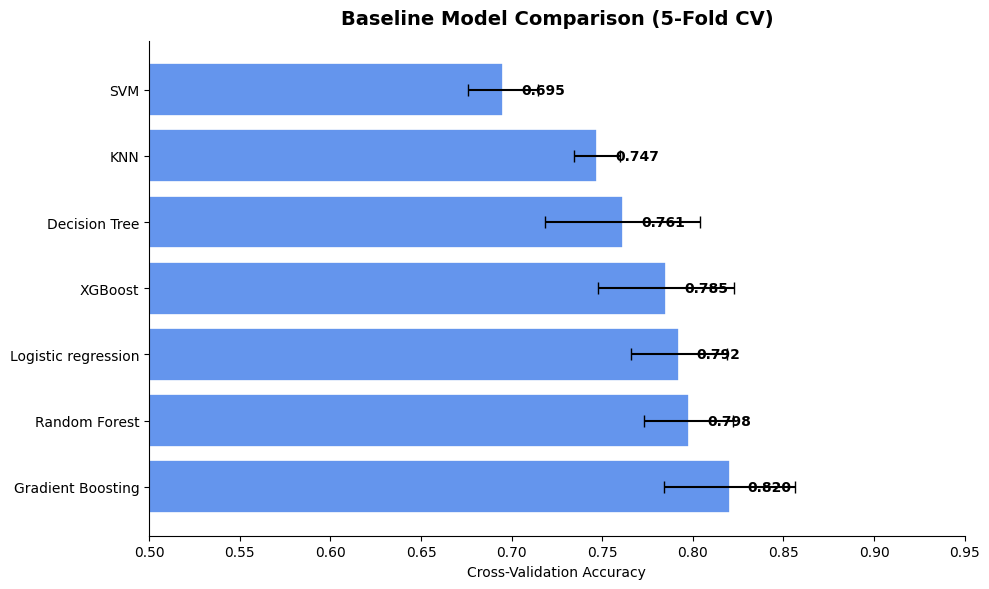

Insight: Tree-based ensembles (Random Forest, XGBoost, Gradient Boosting)
   typically lead here — they handle our mix of binned and categorical features well.


In [106]:
# VISUALIZE MODEL COMPARISON

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(results_df['Model'], results_df['CV Mean Accuracy'],
                xerr=results_df['CV Std'], color='#6495ED',
                edgecolor='white', linewidth=1.2, capsize=4)

ax.set_xlabel('Cross-Validation Accuracy')
ax.set_title('Baseline Model Comparison (5-Fold CV)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlim(0.5, 0.95)

for bar, val in zip(bars, results_df['CV Mean Accuracy']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/07_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Insight: Tree-based ensembles (Random Forest, XGBoost, Gradient Boosting)")
print("   typically lead here — they handle our mix of binned and categorical features well.")

 Hyperparameter Tuning (Top Model)  
 
Why? Once we know which model family performs best, we don't settle for default settings. GridSearchCV systematically tests combinations of hyperparameters using cross-validation, so we find the configuration that generalizes best — not just the one that memorizes training data. We'll tune Random Forest here (swap in XGBoost's params if it won instead).

In [107]:
# HYPERPARAMETER TUNING: RANDOM FOREST

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [4, 6, 8, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Best CV accuracy: 0.8301


Evaluate on Validation Set  

Why? Cross-validation accuracy is good, but now we test on our held-out validation set — data the tuning process never touched. We also go beyond accuracy: confusion matrix shows exactly what kinds of mistakes the model makes, and precision/recall/F1 tell us if it's biased toward predicting survival or death.

In [108]:
# EVALUATE ON VALIDATION SET

from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, roc_auc_score, roc_curve)

y_pred = best_model.predict(X_val)
y_pred_proba = best_model.predict_proba(X_val)[:, 1]

val_accuracy = accuracy_score(y_val, y_pred)
val_auc = roc_auc_score(y_val, y_pred_proba)

print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation ROC-AUC : {val_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=['Did Not Survive', 'Survived']))

Validation Accuracy: 0.7933
Validation ROC-AUC : 0.8377

Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.81      0.86      0.84       110
       Survived       0.76      0.68      0.72        69

       accuracy                           0.79       179
      macro avg       0.79      0.77      0.78       179
   weighted avg       0.79      0.79      0.79       179



Confusion Matrix & ROC Curve

Why? Visuals make model errors tangible. The confusion matrix shows exactly how many people we wrongly predicted would die (false negatives — the costly mistake in this context) versus wrongly predicted would survive. The ROC curve shows how well the model separates the two classes across all thresholds, not just the default 0.5 cutoff.

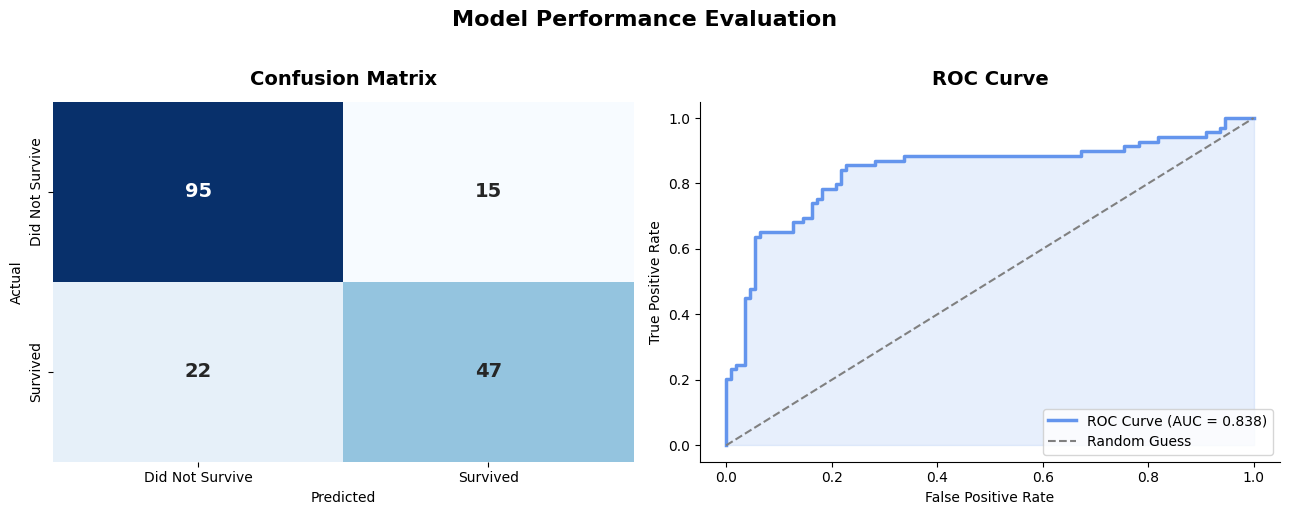

In [109]:
# CONFUSION MATRIX & ROC CURVE

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Did Not Survive', 'Survived'],
            yticklabels=['Did Not Survive', 'Survived'],
            cbar=False, annot_kws={'fontsize': 14, 'fontweight': 'bold'})
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold', pad=12)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
axes[1].plot(fpr, tpr, color='#6495ED', linewidth=2.5, label=f'ROC Curve (AUC = {val_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1.5, label='Random Guess')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold', pad=12)
axes[1].legend(loc='lower right')
axes[1].fill_between(fpr, tpr, alpha=0.15, color='#6495ED')

plt.suptitle('Model Performance Evaluation', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/08_confusion_roc.png', dpi=150, bbox_inches='tight')
plt.show()

 Feature Importance  
 
Why? Before we even get to SHAP, basic feature importance tells us which engineered features the model actually leaned on. This validates whether our feature engineering work (Title, FamilySize, Deck) actually paid off — or whether the model just relied on Sex and Pclass like every beginner notebook.

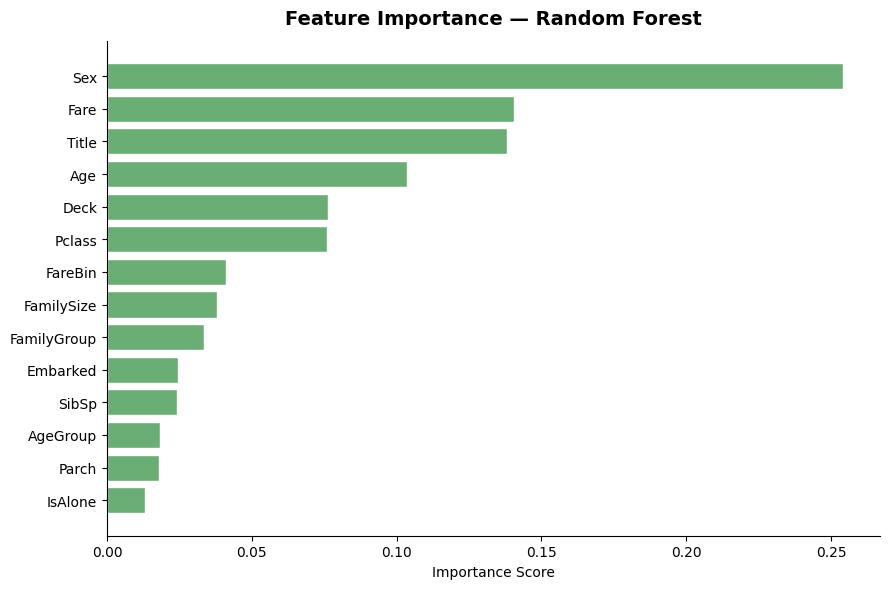

    Feature  Importance
        Sex    0.254213
       Fare    0.140522
      Title    0.138028
        Age    0.103574
       Deck    0.076453
     Pclass    0.076048
    FareBin    0.040930
 FamilySize    0.038135
FamilyGroup    0.033485
   Embarked    0.024635
      SibSp    0.024234
   AgeGroup    0.018458
      Parch    0.018050
    IsAlone    0.013238


In [110]:
# FEATURE IMPORTANCE

importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(importances['Feature'], importances['Importance'], color='#6BAE75', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Feature Importance — Random Forest', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../outputs/09_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(importances.to_string(index=False))

Install & Import SHAP  

Why? Feature importance tells us which features matter overall, but not how each one pushes an individual prediction up or down. SHAP (SHapley Additive exPlanations) gives us that — for any single passenger, we can show exactly why the model predicted survival or death. This is your signature move from the Sommelier AI project, applied here.

In [111]:
# INSTALL & IMPORT SHAP

# !pip install shap   # uncomment and run once if not installed

import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_val)

print("SHAP explainer ready")
print(f"SHAP values shape: {np.array(shap_values).shape}")

SHAP explainer ready
SHAP values shape: (179, 14, 2)


SHAP Summary Plot (Global Explainability)

Why? This is the single most powerful chart in the notebook. It shows every feature's impact across all passengers at once — direction (does high Sex value push survival up or down?) and magnitude together. It's far richer than the basic feature importance bar chart.

<Figure size 1000x700 with 0 Axes>

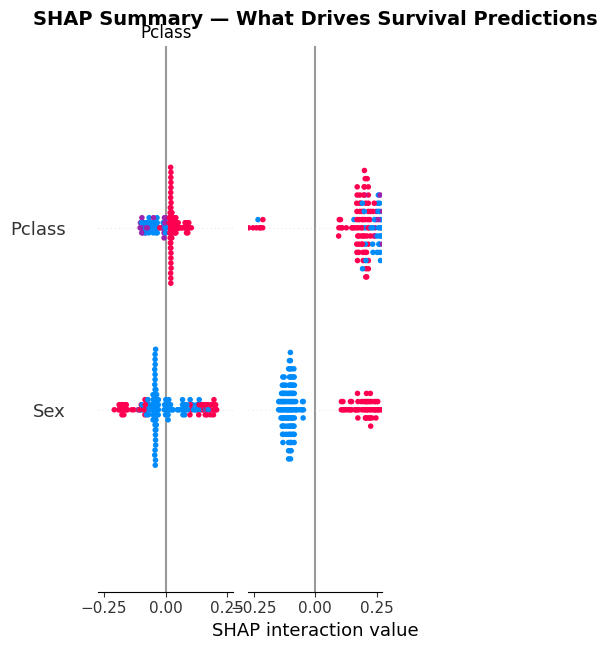

   Insight: Red dots (high feature value) on the right = pushes prediction toward survival.
   Blue dots (low feature value) on the right = also pushes toward survival.
   Position relative to center 0 shows direction; spread shows impact magnitude.


In [112]:
# SHAP SUMMARY PLOT 

# For binary classification, shap_values may be a list [class_0, class_1] or a 2D array
if isinstance(shap_values, list):
    shap_vals_to_plot = shap_values[1]  # class 1 = Survived
else:
    shap_vals_to_plot = shap_values

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals_to_plot, X_val, show=False)
plt.title('SHAP Summary — What Drives Survival Predictions', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../outputs/10_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("   Insight: Red dots (high feature value) on the right = pushes prediction toward survival.")
print("   Blue dots (low feature value) on the right = also pushes toward survival.")
print("   Position relative to center 0 shows direction; spread shows impact magnitude.")

SHAP Waterfall Plot (One Passenger, Explained)

Why? This is the "wow" moment for anyone reviewing your portfolio. We pick one real passenger and show exactly how the model arrived at its prediction — feature by feature. This makes your model feel transparent and trustworthy, not a black box.

Passenger details:
Pclass          3.00
Sex             0.00
Age            24.00
SibSp           2.00
Parch           0.00
Fare           24.15
Embarked        2.00
Title           2.00
FamilySize      3.00
IsAlone         0.00
FamilyGroup     1.00
AgeGroup        4.00
Deck            8.00
FareBin         0.00
Name: 565, dtype: float64

Actual outcome    : Did Not Survive
Predicted outcome : Did Not Survive
Survival probability: 0.278


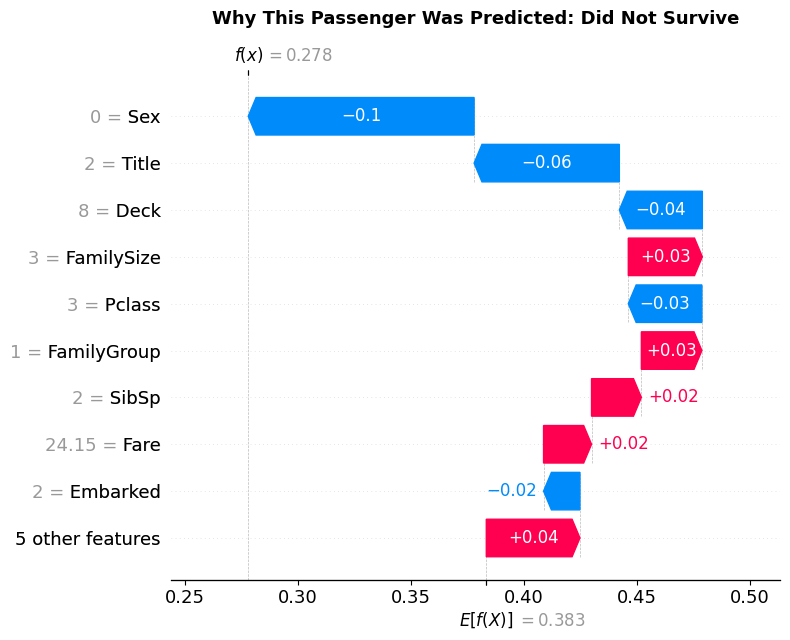

In [114]:
# SHAP WATERFALL — INDIVIDUAL EXPLANATION ---

# Pick a passenger from the validation set, e.g. index 0
idx = 0
passenger_data = X_val.iloc[idx]
actual = y_val.iloc[idx]
predicted = y_pred[idx]
prob = y_pred_proba[idx]

print(f"Passenger details:\n{passenger_data}")
print(f"\nActual outcome    : {'Survived' if actual == 1 else 'Did Not Survive'}")
print(f"Predicted outcome : {'Survived' if predicted == 1 else 'Did Not Survive'}")
print(f"Survival probability: {prob:.3f}")

# Build SHAP Explanation object for waterfall plot
if isinstance(shap_values, list):
    expl = shap.Explanation(
        values=shap_values[1][idx],
        base_values=explainer.expected_value[1],
        data=X_val.iloc[idx],
        feature_names=X_val.columns.tolist()
    )
else:
    expl = shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_val.iloc[idx],
        feature_names=X_val.columns.tolist()
    )

plt.figure(figsize=(10, 6))
# Use class 1 (Survived) for the explanation
expl = shap.Explanation(
    values=shap_values[idx, :, 1],
    base_values=explainer.expected_value[1],
    data=passenger_data,
    feature_names=X_val.columns.tolist()
)

shap.plots.waterfall(expl, show=False)
plt.title(f'Why This Passenger Was Predicted: {"Survived" if predicted==1 else "Did Not Survive"}',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../outputs/11_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

Retrain on Full Training Data

Why? Up to now, our model only learned from 80% of the training data (we held back 20% for validation). Now that we've confirmed the model works well, we retrain on 100% of the available labeled data before making final predictions — more data, better model, since we no longer need a validation holdout.

In [115]:
# RETRAIN ON FULL TRAINING DATA ---

final_model = RandomForestClassifier(**grid_search.best_params_, random_state=42)
final_model.fit(X, y)

print("Final model trained on full training data")
print(f"Training accuracy: {final_model.score(X, y):.4f}")

Final model trained on full training data
Training accuracy: 0.8990


Generate Kaggle Submission File

Why? This is the deliverable. We predict on the actual test set (which has no labels), format it exactly how Kaggle expects (PassengerId, Survived), and save it. This is what you'd upload to the competition.

In [116]:
# GENERATE KAGGLE SUBMISSION ---

test_predictions = final_model.predict(test_clean)

submission = pd.DataFrame({
    'PassengerId': test_ids,
    'Survived': test_predictions.astype(int)
})

submission.to_csv('../outputs/submission.csv', index=False)

print("Submission file saved to ../outputs/submission.csv")
print(f"\nPredicted survival rate: {submission['Survived'].mean():.3f}")
print(f"Actual train survival rate: {y.mean():.3f}")
submission.head(10)

Submission file saved to ../outputs/submission.csv

Predicted survival rate: 0.364
Actual train survival rate: 0.384


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
5,897,0
6,898,0
7,899,0
8,900,1
9,901,0


In [118]:
# --- SANITY CHECK ON SUBMISSION ---
print("Submission shape:", submission.shape)
print("\nPredicted survival rate:", submission['Survived'].mean().round(3))
print("Actual train survival rate:", y.mean().round(3))
print("\nFull value counts:")
print(submission['Survived'].value_counts())

# Should be 418 rows, 2 columns, no missing values
assert submission.shape == (418, 2), "Wrong shape!"
assert submission['Survived'].isnull().sum() == 0, "Missing values found!"
print("\nSubmission file is correctly formatted and ready for Kaggle")

Submission shape: (418, 2)

Predicted survival rate: 0.364
Actual train survival rate: 0.384

Full value counts:
Survived
0    266
1    152
Name: count, dtype: int64

Submission file is correctly formatted and ready for Kaggle


In [121]:
import os
print(os.path.abspath('../outputs'))
print(os.listdir('../outputs'))

c:\Users\FLEX\Desktop\DATA SCIENTIST - Tess Kamau\outputs
['01_survival_overview.png', '02_survival_by_sex.png', '03_survival_by_class.png', '04_survival_by_age.png', '05_family_embarkation.png', '06_fare_correlation.png', '07_model_comparison.png', '08_confusion_roc.png', '09_feature_importance.png', '10_shap_summary.png', '11_shap_waterfall.png', 'submission.csv']
